## World Happiness Report Dataset Summary

**Context**  
The World Happiness Report is a survey of global happiness, first published in 2012. The 2017 report ranks 155 countries by happiness, with governments and organizations using the data to inform policies. Leading experts from various fields describe how well-being measurements assess national progress, and the report explains personal and national variations in happiness.

**Content**  
Happiness scores and rankings use data from the Gallup World Poll (2013-2016), based on responses to the Cantril ladder question (rating life on a scale of 0-10). Six factors contribute to higher happiness: economic production, social support, life expectancy, freedom, absence of corruption, and generosity. These factors don't affect the total score directly but explain why some countries rank higher than others. The lowest scores for these variables represent a hypothetical "Dystopia" used for comparison.

**Inspiration**  
Key questions include:  
- Which countries rank highest in happiness and contributing factors?  
- How did rankings change between 2015-2017?  
- Did any country see a significant increase or decrease in happiness?

**Dystopia**  
Dystopia is a fictional benchmark for the least-happy country, with the lowest possible scores for all six factors. It serves as a comparison point, ensuring all country scores are positive.

**Residuals**  
Residuals reflect how much the six factors either over- or under-explain life evaluations in each country. The residual is combined with the Dystopia score (1.85) to ensure positive values.

**Happiness Score Columns**  
The columns after the Happiness Score (GDP per Capita, Family, Life Expectancy, Freedom, Generosity, Trust in Government) show how these factors contribute to happiness. The Dystopia Residual is the sum of the Dystopia Happiness Score and the residual value for each country. Summing these factors gives the Happiness Score, but predicting happiness based on them may be unreliable.


## Import all relevant libraries

In [1]:
#Import all relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
 
## This statement allows the visuals to render within your Jupyter Notebook.
%matplotlib inline

## Loading the data
We can now load the dataset into pandas using the read_csv() function. This converts the CSV file into a Pandas dataframe.

In [2]:
# Load the datasets for each year into separate DataFrames
df_2015 = pd.read_csv('2015.csv')
df_2016 = pd.read_csv('2016.csv')
df_2017 = pd.read_csv('2017.csv')
df_2018 = pd.read_csv('2018.csv')
df_2019 = pd.read_csv('2019.csv')

### Viewing the dataframe
We can get a quick sense of the size of our dataset by using the shape method. This returns a tuple with the number of rows and columns in the dataset.

In [3]:
# Print the shape of the datasets
print("2015 Dataset shape: ", df_2015.shape)
print("2016 Dataset shape: ", df_2016.shape)
print("2017 Dataset shape: ", df_2017.shape)
print("2018 Dataset shape: ", df_2018.shape)
print("2019 Dataset shape: ", df_2019.shape)

2015 Dataset shape:  (158, 12)
2016 Dataset shape:  (157, 13)
2017 Dataset shape:  (155, 12)
2018 Dataset shape:  (156, 9)
2019 Dataset shape:  (156, 9)


## 1. Data Profiling:
Data profiling is a comprehensive process of examining the data available in an existing dataset and collecting statistics and information about that data. 

The process of profiling differs slightly for categorical and numerical variables due to their inherent differences.

**The two main types of data are:**
- Quantitative (numerical) data
- Qualitative (categorical) data

In [4]:
# 2015 dataset
df_2015.info()
df_2015.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204


In [5]:
# 2016 dataset
df_2016.info()
df_2016.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    object 
 1   Region                         157 non-null    object 
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    flo

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137


In [6]:
# 2017 dataset
df_2017.info()
df_2017.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    object 
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715


In [7]:
# 2018 dataset
df_2018.info()
df_2018.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     155 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408


In [8]:
# 2019 dataset
df_2019.info()
df_2019.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341


### Find the most happiest countries

In [9]:
# Print the most happiest country for each year
print(f'The happiest country in 2015 is {df_2015["Country"][0]} with a score: {df_2015["Happiness Score"][0].round(2)}')
print(f'The happiest country in 2016 is {df_2016["Country"][0]} with a score: {df_2016["Happiness Score"][0].round(2)}')
print(f'The happiest country in 2017 is {df_2017["Country"][0]} with a score: {df_2017["Happiness.Score"][0].round(2)}')
print(f'The happiest country in 2018 is {df_2018["Country or region"][0]} with a score: {df_2018["Score"][0].round(2)}')
print(f'The happiest country in 2019 is {df_2019["Country or region"][0]} with a score: {df_2019["Score"][0].round(2)}')


The happiest country in 2015 is Switzerland with a score: 7.59
The happiest country in 2016 is Denmark with a score: 7.53
The happiest country in 2017 is Norway with a score: 7.54
The happiest country in 2018 is Finland with a score: 7.63
The happiest country in 2019 is Finland with a score: 7.77


In [10]:
# Extract the top 5 happiest countries for each year
top_5_2015 = df_2015['Country'][:5]
top_5_2016 = df_2016['Country'][:5]
top_5_2017 = df_2017['Country'][:5]
top_5_2018 = df_2018['Country or region'][:5]
top_5_2019 = df_2019['Country or region'][:5]

# Print the top 5 happiest countries for each year
print('Top 5 happiest countries in 2015 are:', ', '.join(top_5_2015))
print('Top 5 happiest countries in 2016 are:', ', '.join(top_5_2016))
print('Top 5 happiest countries in 2017 are:', ', '.join(top_5_2017))
print('Top 5 happiest countries in 2018 are:', ', '.join(top_5_2018))
print('Top 5 happiest countries in 2019 are:', ', '.join(top_5_2019))

Top 5 happiest countries in 2015 are: Switzerland, Iceland, Denmark, Norway, Canada
Top 5 happiest countries in 2016 are: Denmark, Switzerland, Iceland, Norway, Finland
Top 5 happiest countries in 2017 are: Norway, Denmark, Iceland, Switzerland, Finland
Top 5 happiest countries in 2018 are: Finland, Norway, Denmark, Iceland, Switzerland
Top 5 happiest countries in 2019 are: Finland, Denmark, Norway, Iceland, Netherlands


In [11]:
# List of top 5 happiest countries for each year
top_5 = [top_5_2015, top_5_2016, top_5_2017, top_5_2018, top_5_2019]

# Find the intersection of all top 5 lists to get countries that are in the top 5 in all years
top_5_countries = set.intersection(*map(set, top_5)) # The * operator unpacks the list of sets, passing them as individual arguments to set.intersection()
print('The top 5 happiest countries in all years are:', ', '.join(top_5_countries))

# Concatenate all top 5 lists into a single series
all_top_5 = pd.concat(top_5)

# Get the frequency of each country in the top 5 lists
top_5_freq = all_top_5.value_counts()

# Print the frequency of each country being in the top 5 across all years
print("\nTop 5 countries and their frequency of being in the top 5 across all years:")
print(top_5_freq)

The top 5 happiest countries in all years are: Iceland, Denmark, Norway

Top 5 countries and their frequency of being in the top 5 across all years:
Iceland        5
Denmark        5
Norway         5
Switzerland    4
Finland        4
Canada         1
Netherlands    1
Name: count, dtype: int64


### Data Quality Checks
Data quality checks involve the process of ensuring that the data is accurate, complete, consistent, relevant, and reliable. 


**Here are typical steps involved in checking data quality:**

#### 1. Reliability:
Evaluate the data's source and collection process to determine its trustworthiness.

- It is reliable because: "The World Happiness Report is a landmark survey of the state of global happiness." in the metadata

#### 2. Timeliness: 
Ensure the data is up-to-date and reflective of the current situation or the period of interest for the analysis.

- Is it up-to-date? No
- Is it in the period of interest? Yes

#### 3. Consistency: 

Confirm that the data is consistent within the dataset and across multiple data sources. For example, the same data point should not have different values in different places.


In [102]:
# List of dataframes for each year
dataframes = [df_2015, df_2016, df_2017, df_2018, df_2019]

# Iterate over each dataframe and print the number of columns and their names
for i, df in enumerate(dataframes, start=2015):
    print(f"Columns in df_{i}: has {len(df.columns)} columns")
    print(", ".join(df.columns))
    print()

Columns in df_2015: has 12 columns
Country, Region, Happiness Rank, Happiness Score, Standard Error, Economy (GDP per Capita), Family, Health (Life Expectancy), Freedom, Trust (Government Corruption), Generosity, Dystopia Residual

Columns in df_2016: has 13 columns
Country, Region, Happiness Rank, Happiness Score, Lower Confidence Interval, Upper Confidence Interval, Economy (GDP per Capita), Family, Health (Life Expectancy), Freedom, Trust (Government Corruption), Generosity, Dystopia Residual

Columns in df_2017: has 12 columns
Country, Happiness.Rank, Happiness.Score, Whisker.high, Whisker.low, Economy..GDP.per.Capita., Family, Health..Life.Expectancy., Freedom, Generosity, Trust..Government.Corruption., Dystopia.Residual

Columns in df_2018: has 9 columns
Overall rank, Country or region, Score, GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, Perceptions of corruption

Columns in df_2019: has 9 columns
Overall rank, Country or regi

In [103]:
# Get the set of columns for each dataframe
columns_sets = [set(df.columns) for df in dataframes]
# Find the intersection of all sets to get the shared columns
shared_columns = set.intersection(*columns_sets)

print("Shared columns in dataframes:", shared_columns)

Shared columns in dataframes: {'Generosity'}


To determine if the datasets are consistent, we need to evaluate:

1. **Column Structure**:  
   - The datasets from 2015 to 2019 have different numbers of columns and names, indicating **inconsistent structure**.

2. **Data Types**:  
   - There is **almost consistency** in data types across the same columns.

3. **Value Consistency**:  
   - There is **almost consistency** in the values.

**Conclusion**:  
For now, the datasets are **not fully consistent**, but they can be made consistent after cleaning and other preprocessing steps.


#### 4. Relevance: 
Assess whether the data is appropriate and applicable for the intended analysis. Data that is not relevant can skew results and lead to incorrect conclusions.

**Key considerations for relevance include:**

> 1. Sample Appropriateness: Confirm that your data sample aligns with your analysis objectives. For instance, utilizing data from the Northern region will not yield accurate insights for the Western region of the Kingdom.
>
> 2. Variable Selection: Any column will not be relevant for our analysis, we can get rid of these using the drop() method. We will set the “axis” argument to 1 since we’re dealing with columns, and set the “inplace” argument to True to make the change permanent.


In [126]:
# There are 195 countries in the world, so we can use this as a reference to check if all countries are present in the datasets
# TODO: Check the missing countries, do we really interested in them?

# Calculate the average number of countries in the datasets
average_countries = int(np.mean([len(df) for df in dataframes]))
print("Average number of countries in datasets: ", average_countries)

# Calculate the difference between the average number of countries and the total number of countries in the world
difference = 195 - average_countries
print("Difference between the average number of countries and the total number of countries in the world: ", difference)

# Calculate the ratio of the average number of countries to the total number of countries in the world
ratio = (np.mean([len(df) for df in dataframes]) / 195).round(2)
print('Ratio of the average number of countries to the total number of countries in the world: ', ratio)

Average number of countries in datasets:  156
Difference between the average number of countries and the total number of countries in the world:  39
Ratio of the average number of countries to the total number of countries in the world:  0.8


For this stage, I will keep all columns in the datasets. This allows for a comprehensive analysis, ensuring that no potentially valuable information is discarded at this point.
During the cleaning step, I will evaluate each column's relevance and select the specific variables necessary to address the analysis objectives.

#### 5. Uniqueness: 
Check for and remove duplicate records to prevent skewed analysis results.


In [115]:
print("Number of duplicated in df_2015 =",df_2015.duplicated().sum())
print("Number of duplicated in df_2016 =",df_2016.duplicated().sum())
print("Number of duplicated in df_2017 =",df_2017.duplicated().sum())
print("Number of duplicated in df_2018 =",df_2018.duplicated().sum())
print("Number of duplicated in df_2019 =",df_2019.duplicated().sum())

Number of duplicated in df_2015 = 0
Number of duplicated in df_2016 = 0
Number of duplicated in df_2017 = 0
Number of duplicated in df_2018 = 0
Number of duplicated in df_2019 = 0


As we can see, all datasets have no duplicated values.

#### 6. Completeness: 
Ensure that no critical data is missing. This might mean checking for null values or required fields that are empty.

We will start by checking the dataset for missing or null values. For this, we can use the isna() method which returns a dataframe of boolean values indicating if a field is null or not. To group all missing values by column, we can include the sum() method.

In [125]:
print("Number of missing values in df_2015 =",df_2015.isnull().sum().sum())
print("Number of missing values in df_2016 =",df_2016.isnull().sum().sum())
print("Number of missing values in df_2017 =",df_2017.isnull().sum().sum())
print("Number of missing values in df_2018 =",df_2018.isnull().sum().sum())
print("Number of missing values in df_2019 =",df_2019.isnull().sum().sum())

# Check for missing values in each column
df_2018[df_2018['Perceptions of corruption'].isnull()]

# TODO: Solve the missing values in the column 'Perceptions of corruption' in the 2018 dataset using the mean of the column, or any other method fit.

Number of missing values in df_2015 = 0
Number of missing values in df_2016 = 0
Number of missing values in df_2017 = 0
Number of missing values in df_2018 = 1
Number of missing values in df_2019 = 0


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
19,20,United Arab Emirates,6.774,2.096,0.776,0.67,0.284,0.186,NaN


In [60]:
# df_2015 missing values
print("df_2015 info:-")
df_2015.info() # Check for missing values in each column and the data types of the columns

# Check for non-alphabetical characters in the 'Country' column
# This regex pattern checks if the 'Country' column contains only alphabetical characters and spaces
df_2015[df_2015['Country'].str.contains('^![a-zA-Z]+$') | df_2015['Region'].str.contains('^![a-zA-Z]+$')] # # Check for non-alphabetical characters in the two columns


# There are no non-alphabetical characters in the 'Country' and 'Region' columns

df_2015 info:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual


In [61]:
# df_2016 missing values
print("df_2016 info:-")
df_2016.info() # Check for missing values in each column and the data types of the columns

df_2016[df_2016['Region'].str.contains('^![a-zA-Z]+$') | df_2016['Country'].str.contains('^![a-zA-Z]+$')] # Check for non-alphabetical characters in the two columns

# There are no non-alphabetical characters in the 'Country' and 'Region' columns

df_2016 info:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    object 
 1   Region                         157 non-null    object 
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual


In [54]:
# df_2017 missing values
print("df_2017 info:-")
df_2017.info() # Check for missing values in each column and the data types of the columns

# Check for non-alphabetical characters in the 'Country' column
# This regex pattern checks if the 'Country' column contains only alphabetical characters and spaces
df_2017[df_2017['Country'].str.contains('^![a-zA-Z]+$')]

# There are no non-alphabetical characters in the 'Country' column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    object 
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual


In [45]:
# df_2018 missing values
print("df_2018 info:-")
df_2018.info() # Check for missing values in each column and the data types of the columns

# Check for non-alphabetical characters in the 'Country or region' column
# This regex pattern checks if the 'Country' column contains only alphabetical characters and spaces
df_2018[df_2018['Country or region'].str.contains('^![a-zA-Z ]+$')]

# There are no non-alphabetical characters in the 'Country or region' column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     155 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption


In [62]:
# df_2019 missing values

print("df_2019 info:-")
df_2019.info() # Check for missing values in each column and the data types of the columns

# Check for non-alphabetical characters in the 'column
# This regex pattern checks if the column contains only alphabetical characters and spaces
df_2019[df_2019['Country or region'].str.contains('^![a-zA-Z ]+$')]

# There are no non-alphabetical characters in the column

df_2019 info:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption


#### 7. Check Accuracy:

Verify that the data is correct and precise. This could involve comparing data samples with known sources or using validation rules.

**The process includes:**
1. Validating the appropriateness of data types for the dataset.
2. Identifying outliers  using established validation  rule

In [2]:
# Regarding dtypes, all columns are already in a suitable format for analysis. There is no need to change the data types of any column.

In [18]:
# We will fix the missing values in the 'Perceptions of corruption' column in the 2018 dataset by filling them with the mean of the column.
87
df_2018[df_2018['Perceptions of corruption'].isnull()] # Check the rows with missing values in the 'Perceptions of corruption' column

df_2018['Perceptions of corruption'].describe() # Get the summary statistics of the 'Perceptions of corruption' column

df_2018['Perceptions of corruption'].fillna(-1 , inplace=True) # Fill the missing values in the 'Perceptions of corruption' column with the -1 value

In [3]:
# check outliers 

**What is an Outlier?** 
Outlier is an row/observation that appears far away and diverges from an overall pattern in a sample.

**What are the types of Outliers?**
1. Univariate: These outliers can be found when we look at distribution of a single variable
2. Multivariate: are outliers in an n-dimensional space. In order to find them, you have to look at distributions in multi-dimensions. example (hight=100, weight=100) for a person

**What causes Outliers?**
Whenever we come across outliers, the ideal way to tackle them is to find out the reason of having these outliers. The method to deal with them would then depend on the reason of their occurrence.

Let’s understand various types of outliers:

1. Data Entry Errors:- Human errors such as errors caused during data collection, recording, or entry can cause outliers in data.
2. Measurement Error: It is the most common source of outliers. This is caused when the measurement instrument used turns out to be faulty.
3. Data Processing Error: Whenever we perform data mining, we extract data from multiple sources. It is possible that some manipulation or extraction errors may lead to outliers in the dataset.
4. Sampling error: For instance, we have to measure the height of athletes. By mistake, we include a few basketball players in the sample. This inclusion is likely to cause outliers in the dataset.
5. Natural Outlier: When an outlier is not artificial (due to error), it is a natural outlier. For instance: In my last assignment with one of the renowned insurance company, I noticed that the performance of top 50 financial advisors was far higher than rest of the population. Surprisingly, it was not due to any error. Hence, whenever we perform any data mining activity with advisors, we used to treat this segment separately.


**What is the impact of Outliers on a dataset?**


![image.png](https://www.analyticsvidhya.com/wp-content/uploads/2015/02/Outlier_31.png)



**How to detect Outliers?**

1. Most commonly used method to detect outliers is visualization (Univariate Graphical Analysis).

We use 3 common visualization methods:
>- Box-plot: A box plot is a method for graphically depicting groups of numerical data through their quartiles. The box extends from the Q1 to Q3 quartile values of the data, with a line at the median (Q2). The whiskers extend from the edges of the box to show the range of the data. Outlier points are those past the end of the whiskers. Box plots show robust measures of location and spread as well as providing information about symmetry and outliers.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:698/format:webp/1*VK5iHA2AB28HSZwWwUbNYg.png)
>
>
>- Histogram
>- Scatter Plot: A scatter plot is a mathematical diagram using Cartesian coordinates to display values for two variables for a set of data. The data are displayed as a collection of points, each having the value of one variable determining the position on the horizontal axis and the value of the other variable determining the position on the vertical axis. The points that are far from the population can be termed as an outlier.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*Ov6aH-8yIwNoUxtMFwgx4g.png)
>
>

2. Using statistical method (Univariate Non-Graphical analysis):
>- Any value, which is beyond the range of -1.5 x IQR to 1.5 x IQR
 
![image.png](https://www.whatissixsigma.net/wp-content/uploads/2015/07/Box-Plot-Diagram-to-identify-Outliers-figure-1.png)

>- Use capping methods. Any value which out of range of 5th and 95th percentile can be considered as outlier
>- Data points, three or more standard deviation away from mean are considered outlier: The Z-score is the signed number of standard deviations by which the value of an observation or data point is above the mean value of what is being observed or measured. While calculating the Z-score we re-scale and center the data and look for data points that are too far from zero. These data points which are way too far from zero will be treated as the outliers. In most of the cases, a threshold of 3 or -3 is used i.e if the Z-score value is greater than or less than 3 or -3 respectively, that data point will be identified as outliers.
> - Outlier detection is merely a special case of the examination of data for influential data points and it also depends on the business understanding


In [23]:
# go to univariate graphical analysis
# go to lesson : data visualisation 1 - chart type section
# then go to univariate graphical analysis
# detect outliers using graphs varbaly

In [24]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysis
# detect outliers using numerical statistics 

## 2. Data Cleaning: 

Preliminary findings from data profiling can lead to cleaning the data by:
- Handling missing values
- Correcting errors.
- Dealing with outliers.

-------------------



### Handling missing values:

**Why my data has missing values?**
They may occur at two stages:
1. Data Extraction: It is possible that there are problems with extraction process. Errors at data extraction stage are typically easy to find and can be corrected easily as well.
2. Data collection: These errors occur at time of data collection and are harder to correct.

**Why do we need to handle the missing data?**
To avoid:
- Bias the conclusions.
- Leading the business to make wrong decisions.

**Which are the methods to treat missing values ?**
1. Deletion: we delete rows where any of the variable is missing. Simplicity is one of the major advantage of this method, but this method reduces the power of model because it reduces the sample size.

2. Imputation: is a method to fill in the missing values with estimated ones. This imputation is one of the most frequently used methods.

    2.1. Mean/ Mode/ Median Imputation: It consists of replacing the missing data for a given attribute by the mean or median (quantitative attribute) or mode (qualitative attribute) of all known values of that variable.
    > It can be of two types:
    > - Generalized Imputation: In this case, we calculate the mean or median for all non missing values of that variable then replace missing value with mean or median.
    > - Similar case Imputation: In this case, we calculate average for each group individually of non missing values then replace the missing value based on the group.

    2.2. Constant Value
   
    2.3. Forward Filling
   
    2.4. Backward Filling

6. Prediction Model:  Prediction model is one of the sophisticated method for handling missing data. Here, we create a predictive model to estimate values that will substitute the missing data.  In this case, we divide our data set into two sets: One set with no missing values for the variable and another one with missing values. First data set become training data set of the model while second data set with missing values is test data set and variable with missing values is treated as target variable. Next, we create a model to predict target variable based on other attributes of the training data set and populate missing values of test data set.

> There are 2 drawbacks for this approach:
> - The model estimated values are usually more well-behaved than the true values
> - If there are no relationships with attributes in the data set and the attribute with missing values, then the model will not be precise for estimating missing values.

9. KNN Imputation: In this method of imputation, the missing values of an attribute are imputed using the given number of attributes that are most similar to the attribute whose values are missing. The similarity of two attributes is determined using a distance function. It is also known to have certain advantage & disadvantages.

   > **Advantages:**
   > - k-nearest neighbour can predict both qualitative & quantitative attributes
   > - Creation of predictive model for each attribute with missing data is not required
   > - Attributes with multiple missing values can be easily treated
   > - Correlation structure of the data is taken into consideration

   > **Disadvantage:**
   > - KNN algorithm is very time-consuming in analyzing large database. It searches through all the dataset looking for the most similar instances.
   > - Choice of k-value is very critical. Higher value of k would include attributes which are significantly different from what we need whereas lower value of k implies missing out of significant attributes.

--------------------


### Correcting errors

-------------------

In [12]:
df_2018[df_2018.isnull().any(axis=1)] # Check if there are any rows with missing values in the dataset

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
19,20,United Arab Emirates,6.774,2.096,0.776,0.67,0.284,0.186,NaN


In [14]:
df_2018.fillna(-0.3, inplace=True) # Fill missing values in the dataset with the mean of the column

In [15]:
df_2018[df_2018.isnull().any(axis=1)] # Check if there are any rows with missing values in the dataset

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption


In [16]:
df_2018['Perceptions of corruption'].describe() # Get the summary statistics of the 'Perceptions of corruption' column

count    156.000000
mean       0.104872
std        0.131062
min       -1.000000
25%        0.050750
50%        0.082000
75%        0.136500
max        0.457000
Name: Perceptions of corruption, dtype: float64

<Axes: >

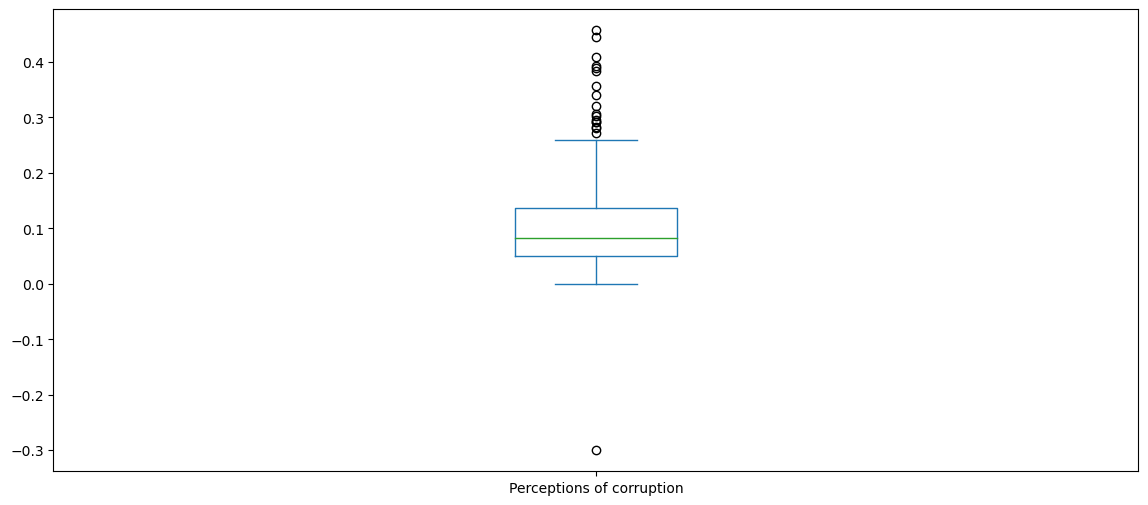

In [21]:
df_2018['Perceptions of corruption'].plot(kind='box', figsize=(14, 6)) # Plot a boxplot of the 'Perceptions of corruption' column

### Dealing with outliers:

**How to remove Outliers?**
Most of the ways to deal with outliers are similar to the methods of missing values like deleting rows, transforming them, binning them, treat them as a separate group, imputing values and other statistical methods. Here, we will discuss the common techniques used to deal with outliers:

1. Deleting rows: We delete outlier values if it is due to data entry error, data processing error or outlier rows are very small in numbers. We can also use trimming at both ends to remove outliers.

2. Imputing: Like imputation of missing values, we can also impute outliers. We can use mean, median, mode imputation methods. Before imputing values, we should analyse if it is natural outlier or artificial. If it is artificial, we can go with imputing values. We can also use statistical model to predict values of outlier rows and after that we can impute it with predicted values.

3. Treat separately: If there are significant number of outliers, we should treat them separately in the statistical model. One of the approach is to treat both groups as two different groups and build individual model for both groups and then combine the output.


## 3. Univariate Analysis: 

This involves examining single variables to understand their characteristics (distribution, central tendency, dispersion, and shape).

We calculate **numerical values** about the data that tells us about the distribution of the data. We also **draw graphs** showing visually how the data is distributed. **To answer the following questions about Features/characteristics of Data:**
- Where is the center of the data? (location)
- How much does the data vary? (scale)
- What is the shape of the data? (shape)

**The benefits of this analysis:**
Statistics summary gives a high-level idea to identify whether the data has any outliers, data entry error, distribution of data such as the data is normally distributed or left/right skewed

**In this step, we will explore variables one by one using following approaches:**

### 1. Univariate Graphical Analysis:
Method to perform uni-variate analysis will depend on whether the variable type is categorical or numerical.

#### I. Categorical Variables:

we’ll use frequency table to understand distribution of each category
- Bar Chart (Ordinal) - Orderd
- Pie Chart (Nominal) - non Orderd

#### II. Numerical Variables:

we need to understand the central tendency and spread of the variable (Descriptive Analysis) using:
   - Box plot
   - Histogram

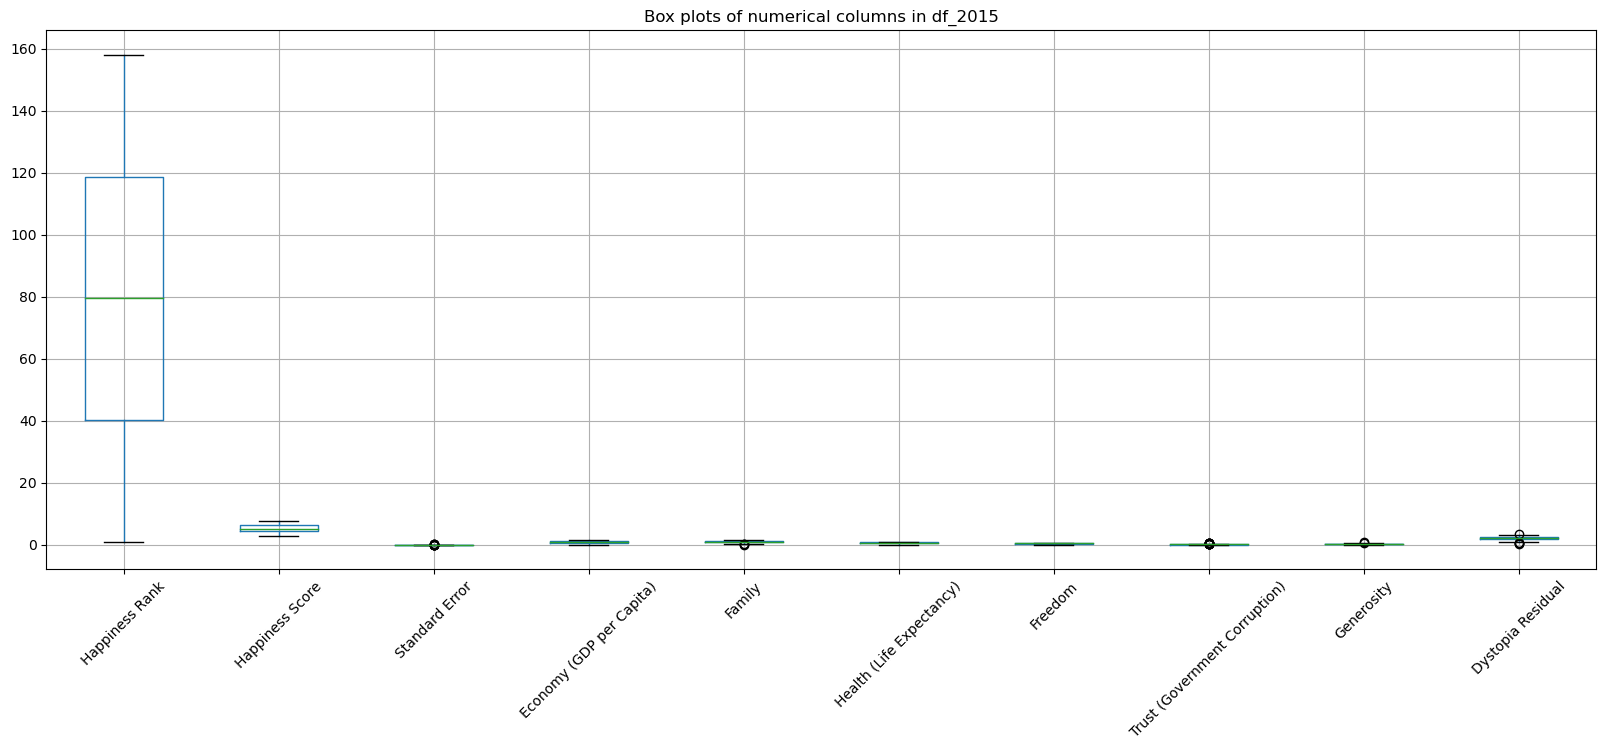

In [29]:
# Plot box plots for each numerical column to check for outliers
numerical_columns = df_2015.select_dtypes(include=['number']).columns
plt.figure(figsize=(20, 7))
df_2015[numerical_columns].boxplot()
plt.xticks(rotation=45)
plt.title('Box plots of numerical columns in df_2015')
plt.show()

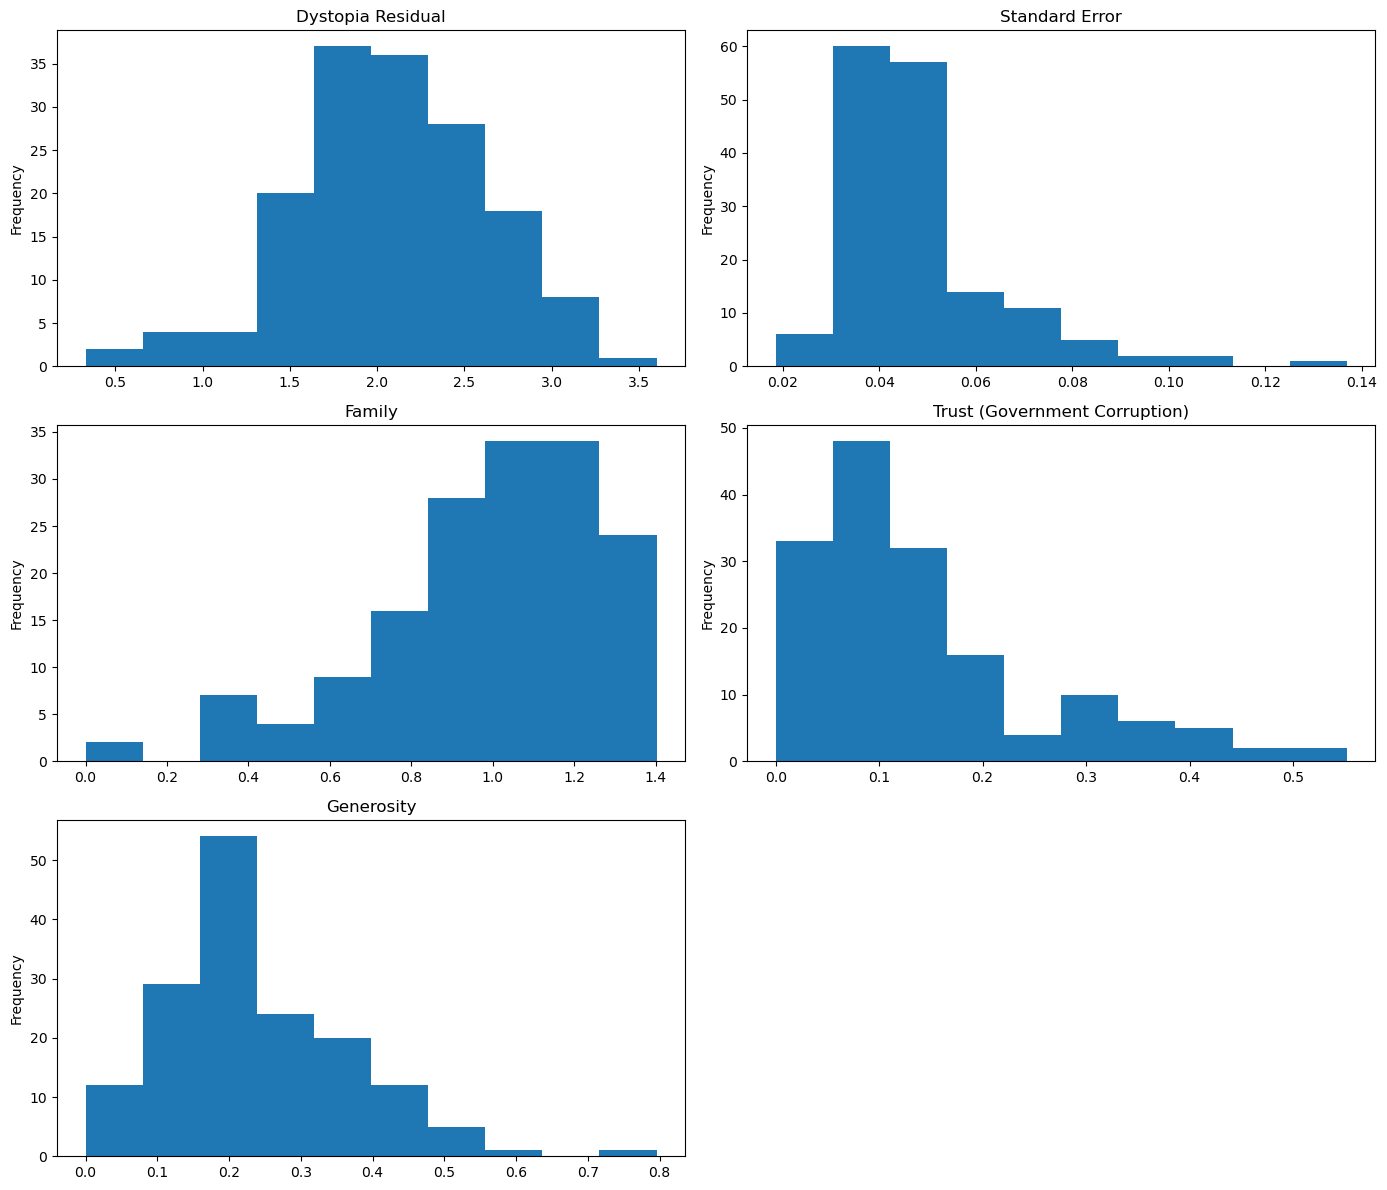

In [50]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12)) # Create a 3x2 grid of subplots

# Plot a histogram of the 'Dystopia Residual' column
df_2015['Dystopia Residual'].plot(kind='hist', ax=axes[0, 0], title='Dystopia Residual')

# Plot a histogram of the 'Standard Error' column
df_2015['Standard Error'].plot(kind='hist', ax=axes[0, 1], title='Standard Error')

# Plot a histogram of the 'Family' column
df_2015['Family'].plot(kind='hist', ax=axes[1, 0], title='Family')

# Plot a histogram of the 'Trust (Government Corruption)' column
df_2015['Trust (Government Corruption)'].plot(kind='hist', ax=axes[1, 1], title='Trust (Government Corruption)')

# Plot a histogram of the 'Generosity' column
df_2015['Generosity'].plot(kind='hist', ax=axes[2, 0], title='Generosity')

fig.delaxes(axes[2, 1]) # Hide the empty subplot (axes[2, 1])

plt.tight_layout() 
plt.show()

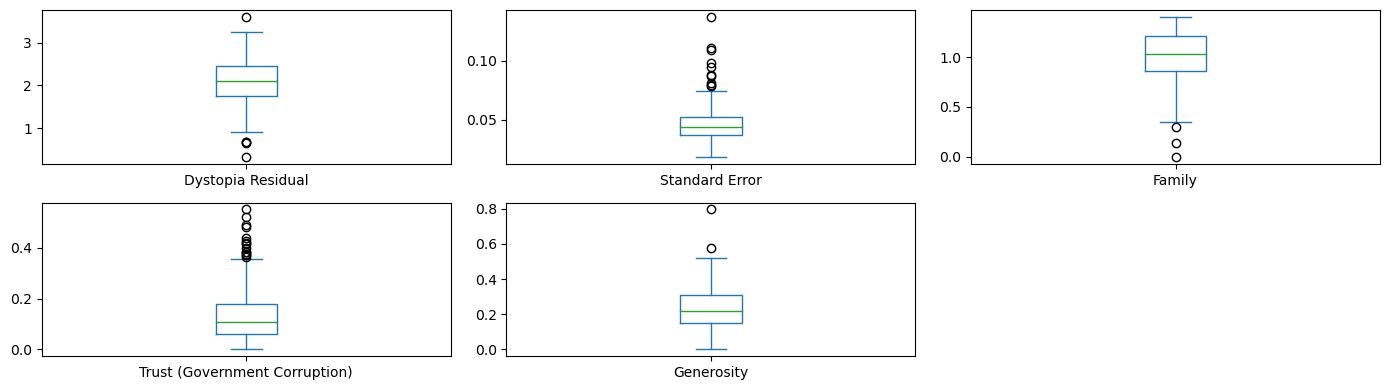

In [52]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 4)) # Create a 3x2 grid of subplots

# Plot a boxplot of the 'Dystopia Residual' column
df_2015['Dystopia Residual'].plot(kind='box', ax=axes[0, 0])

# Plot a boxplot of the 'Standard Error' column
df_2015['Standard Error'].plot(kind='box', ax=axes[0, 1])

# Plot a boxplot of the 'Family' column
df_2015['Family'].plot(kind='box', ax=axes[0, 2])

# Plot a boxplot of the 'Trust (Government Corruption)' column
df_2015['Trust (Government Corruption)'].plot(kind='box', ax=axes[1, 0])

df_2015['Generosity'].plot(kind='box', ax=axes[1, 1])

fig.delaxes(axes[1, 2]) # Hide the empty subplot (axes[2, 1])

plt.tight_layout() 
plt.show()

In [54]:
# Calculate the Z-scores for each numerical column
z_scores = np.abs(zscore(df_2015[numerical_columns]))

# Set a threshold for identifying outliers
threshold = 3

# Identify rows where any Z-score is greater than the threshold
outliers = np.where(z_scores > threshold)

# Print the rows that are considered outliers
print("Outlier rows:")
df_2015.iloc[outliers[0]]

# Are those outliers should be removed or not?

Outlier rows:


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
27,Qatar,Middle East and Northern Africa,28,6.611,0.06257,1.69042,1.07860,0.79733,0.64040,0.52208,0.32573,1.55674
40,Trinidad and Tobago,Latin America and Caribbean,41,6.168,0.10895,1.21183,1.18354,0.61483,0.55884,0.01140,0.31844,2.26882
64,Jamaica,Latin America and Caribbean,65,5.709,0.13693,0.81038,1.15102,0.68741,0.50442,0.02299,0.21230,2.32038
115,Liberia,Sub-Saharan Africa,116,4.571,0.11068,0.07120,0.78968,0.34201,0.28531,0.06232,0.24362,2.77729
128,Myanmar,Southeastern Asia,129,4.307,0.04351,0.27108,0.70905,0.48246,0.44017,0.19034,0.79588,1.41805
147,Central African Republic,Sub-Saharan Africa,148,3.678,0.06112,0.07850,0.00000,0.06699,0.48879,0.08289,0.23835,2.72230
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
157,Togo,Sub-Saharan Africa,158,2.839,0.06727,0.20868,0.13995,0.28443,0.36453,0.10731,0.16681,1.56726


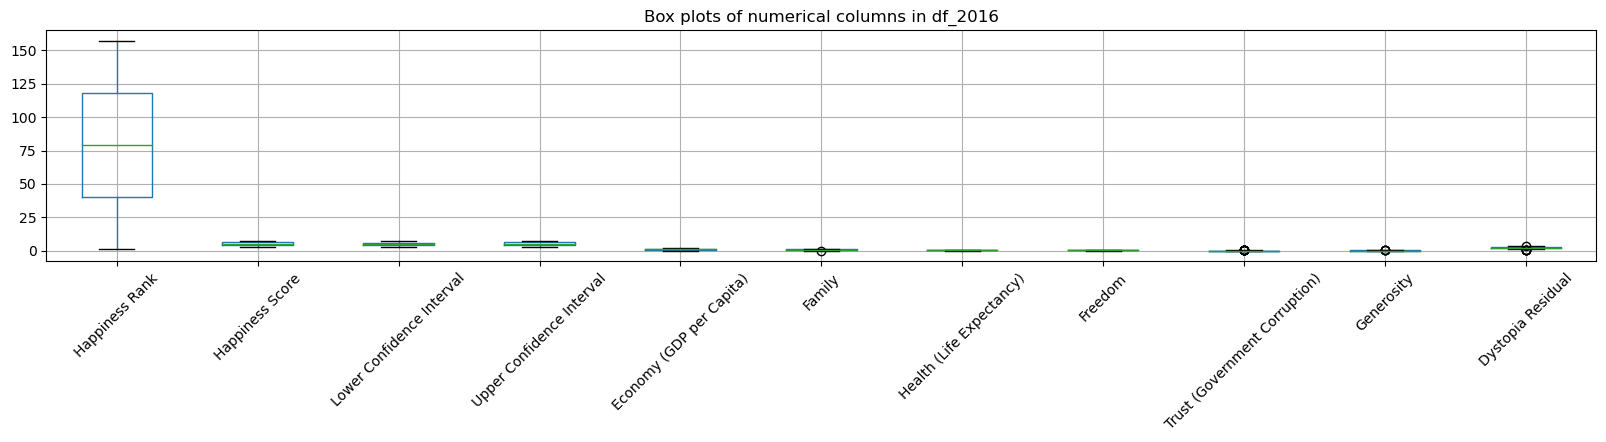

In [60]:
numerical_columns_16 = df_2016.select_dtypes(include=['number']).columns

plt.figure(figsize=(20, 3))
df_2016[numerical_columns_16].boxplot()
plt.xticks(rotation=45)
plt.title('Box plots of numerical columns in df_2016')
plt.show()

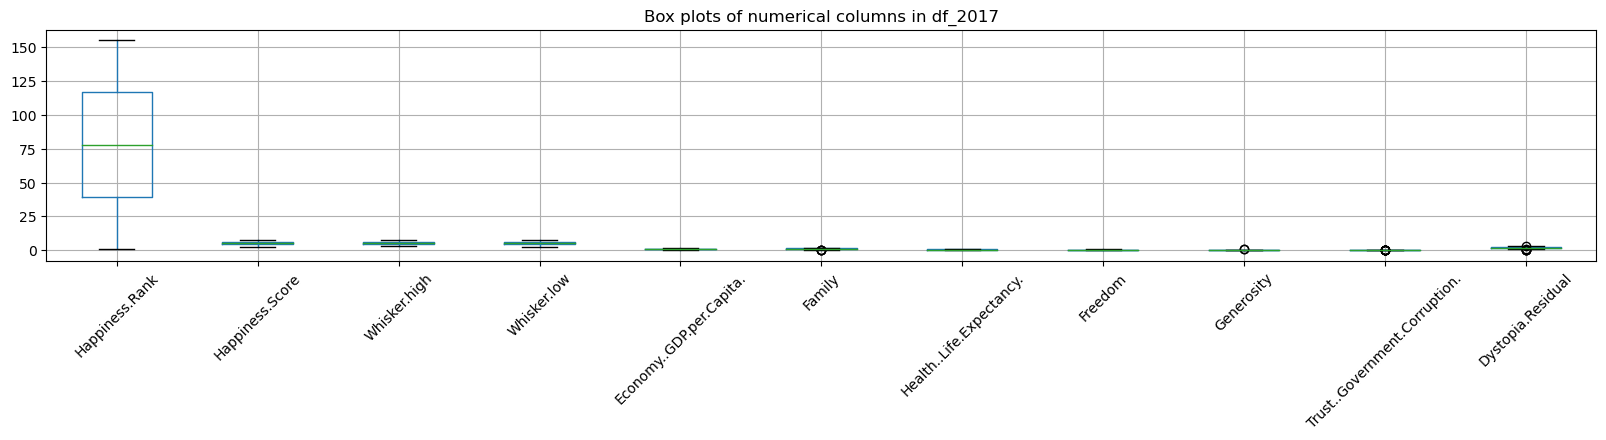

In [59]:
numerical_columns_17 = df_2017.select_dtypes(include=['number']).columns

plt.figure(figsize=(20, 3))

df_2017[numerical_columns_17].boxplot()
plt.xticks(rotation=45)
plt.title('Box plots of numerical columns in df_2017')
plt.show()

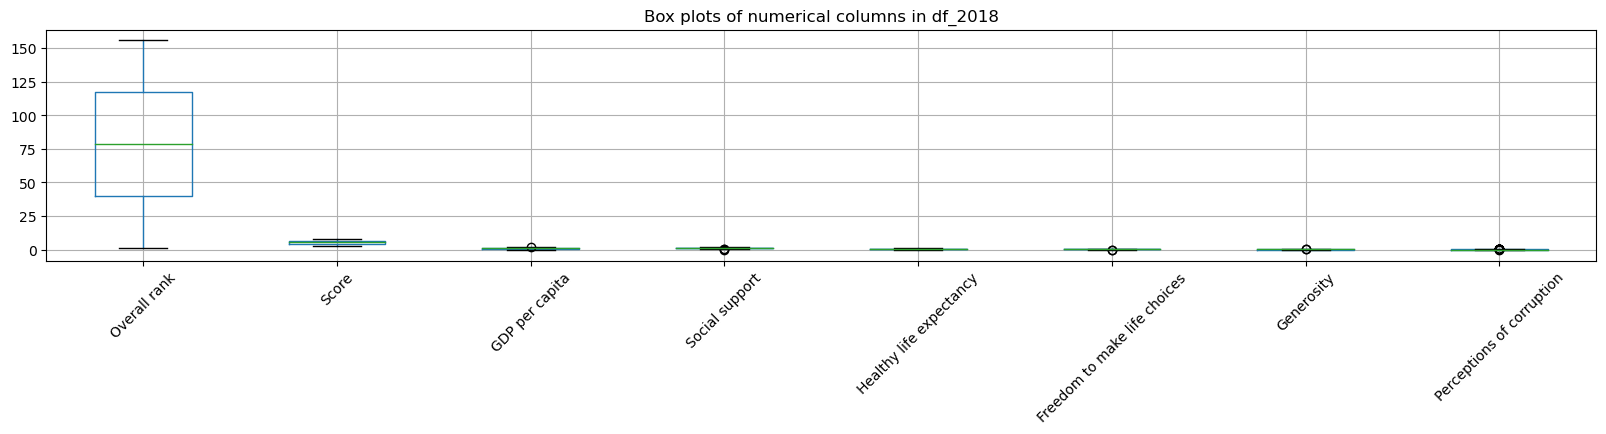

In [64]:
numerical_columns_18 = df_2018.select_dtypes(include=['number']).columns

plt.figure(figsize=(20, 3))

df_2018[numerical_columns_18].boxplot()

plt.xticks(rotation=45)

plt.title('Box plots of numerical columns in df_2018')

plt.show()

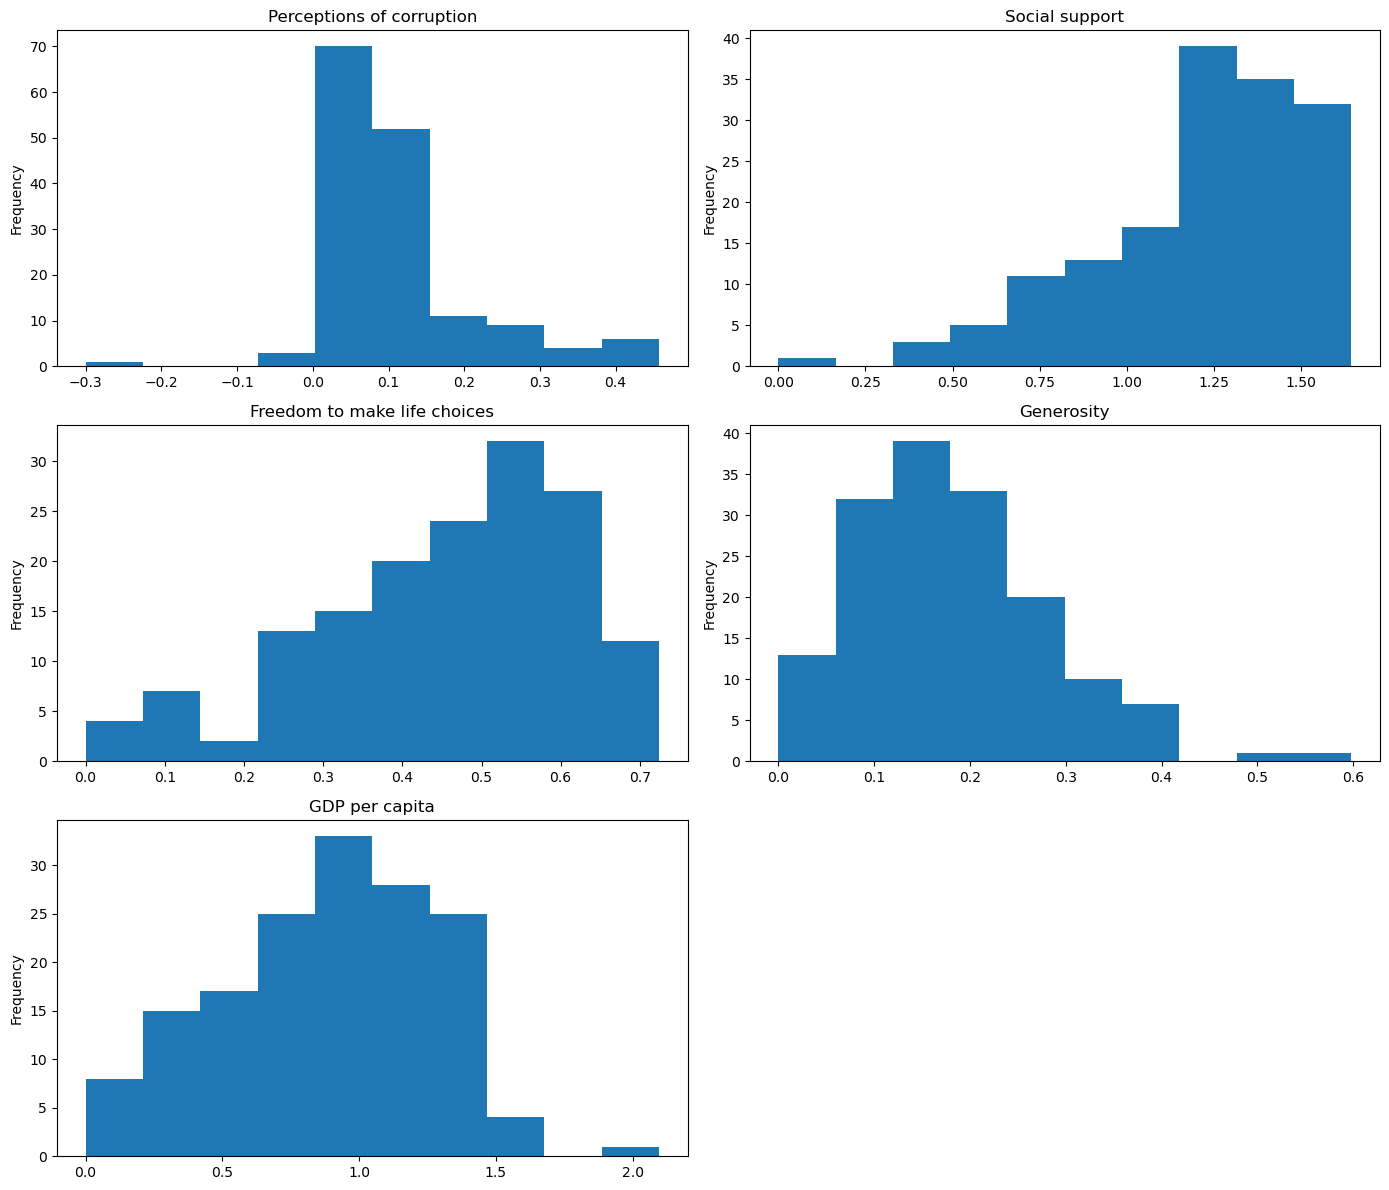

In [65]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12)) # Create a 3x2 grid of subplots

# Plot a histogram of the 'Dystopia Residual' column
df_2018['Perceptions of corruption'].plot(kind='hist', ax=axes[0, 0], title='Perceptions of corruption')

# Plot a histogram of the 'Standard Error' column
df_2018['Social support'].plot(kind='hist', ax=axes[0, 1], title='Social support')

# Plot a histogram of the 'Family' column
df_2018['Freedom to make life choices'].plot(kind='hist', ax=axes[1, 0], title='Freedom to make life choices')

# Plot a histogram of the 'Generosity' column
df_2018['Generosity'].plot(kind='hist', ax=axes[1, 1], title='Generosity')

# Plot a histogram of the 'GDP per capita' column
df_2018['GDP per capita'].plot(kind='hist', ax=axes[2, 0], title='GDP per capita')

fig.delaxes(axes[2, 1]) # Hide the empty subplot (axes[2, 1])

plt.tight_layout()  
plt.show()

<Axes: >

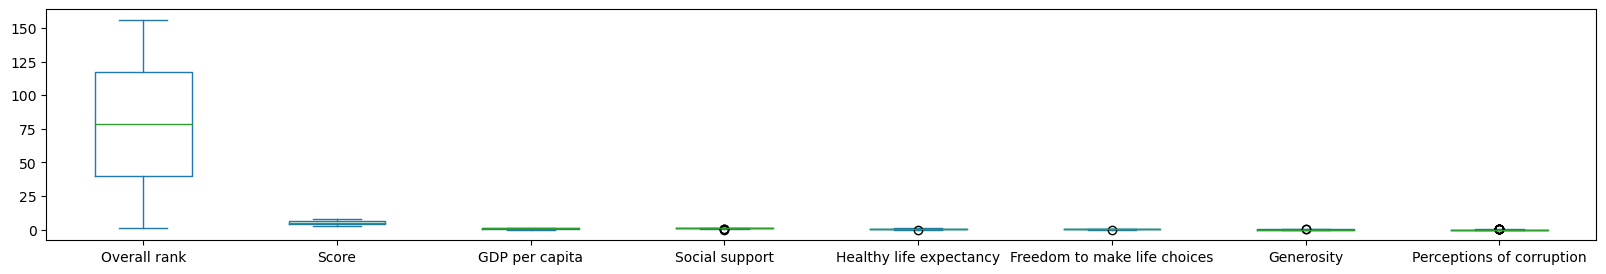

In [72]:
numerical_columns_19 = df_2019.select_dtypes(include=['number']).columns

df_2019[numerical_columns_19].plot(kind='box', figsize=(20, 3))

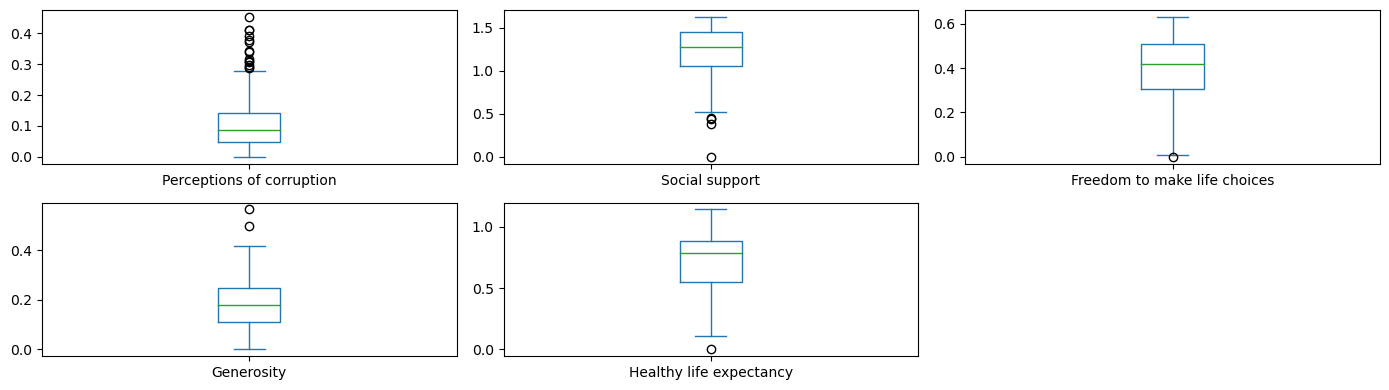

In [73]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 4)) # Create a 3x2 grid of subplots

# Plot a boxplot of the 'Perceptions of corruption' column
df_2019['Perceptions of corruption'].plot(kind='box', ax=axes[0, 0])

# Plot a boxplot of the 'Social support' column
df_2019['Social support'].plot(kind='box', ax=axes[0, 1])

# Plot a boxplot of the 'Freedom to make life choices' column
df_2019['Freedom to make life choices'].plot(kind='box', ax=axes[0, 2])

# Plot a boxplot of the 'Generosity' column
df_2019['Generosity'].plot(kind='box', ax=axes[1, 0])

# Plot a boxplot of the 'Healthy life expectancy' column
df_2019['Healthy life expectancy'].plot(kind='box', ax=axes[1, 1])

fig.delaxes(axes[1, 2]) # Hide the empty subplot (axes[2, 1])

plt.tight_layout()
plt.show()

- Q1: What countries or regions rank the highest in overall happiness and each of the six factors contributing to happiness? 
- Q2: How did country ranks or scores change between the 2015 and 2016 as well as the 2016 and 2017 reports? 
- Q3: Did any country experience a significant increase or decrease in happiness?

#### Q1
We will use 2018&2019 dataframes because it has six factors

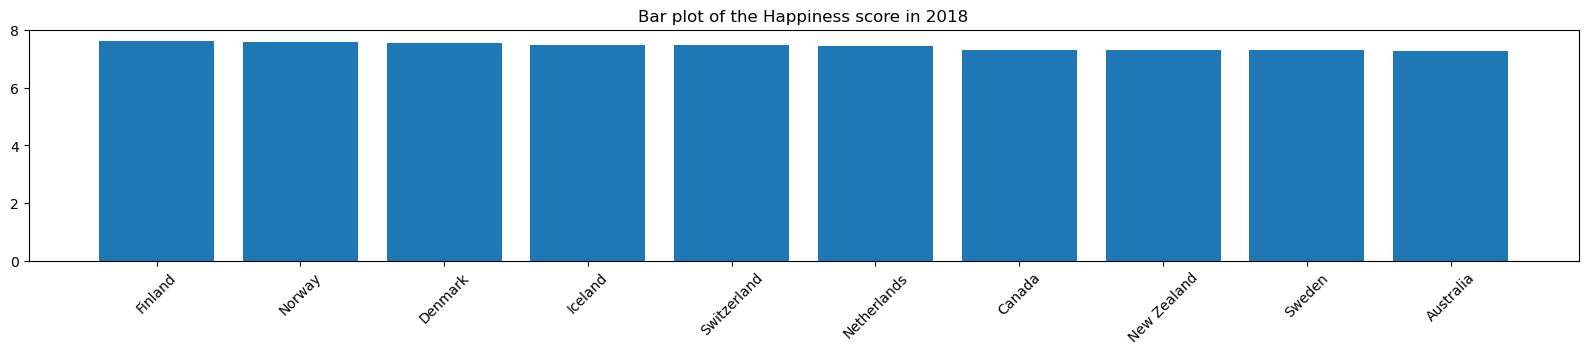

In [80]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(20, 3))

# Plot a bar chart for the top 10 countries in 2018 based on their happiness score
plt.bar(df_2018['Country or region'][:10], df_2018['Score'][:10])

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Set the title of the plot
plt.title('Bar plot of the Happiness score in 2018')

# Display the plot
plt.show()

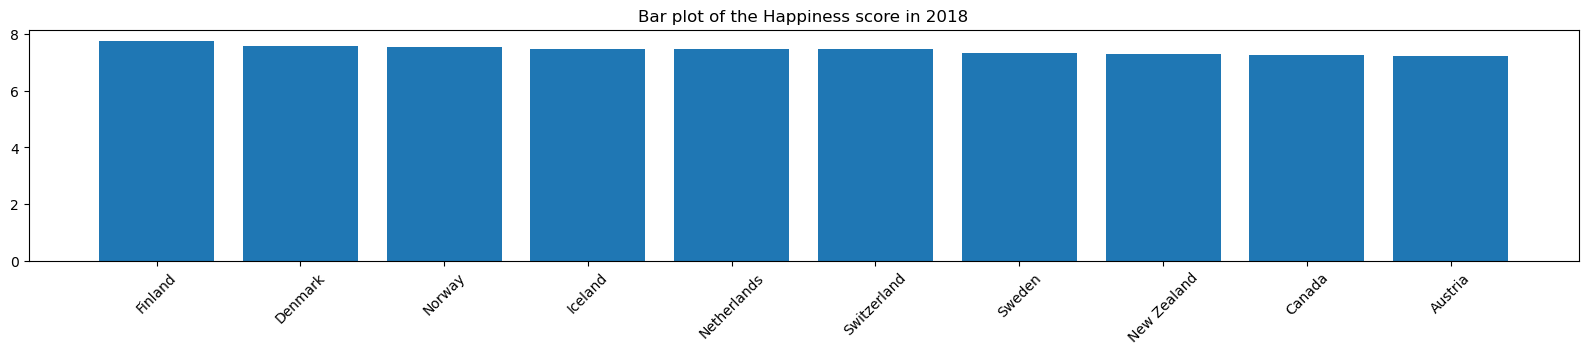

In [81]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(20, 3))

# Plot a bar chart for the top 10 countries in 2018 based on their happiness score
plt.bar(df_2019['Country or region'][:10], df_2019['Score'][:10])

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Set the title of the plot
plt.title('Bar plot of the Happiness score in 2019')

# Display the plot
plt.show()

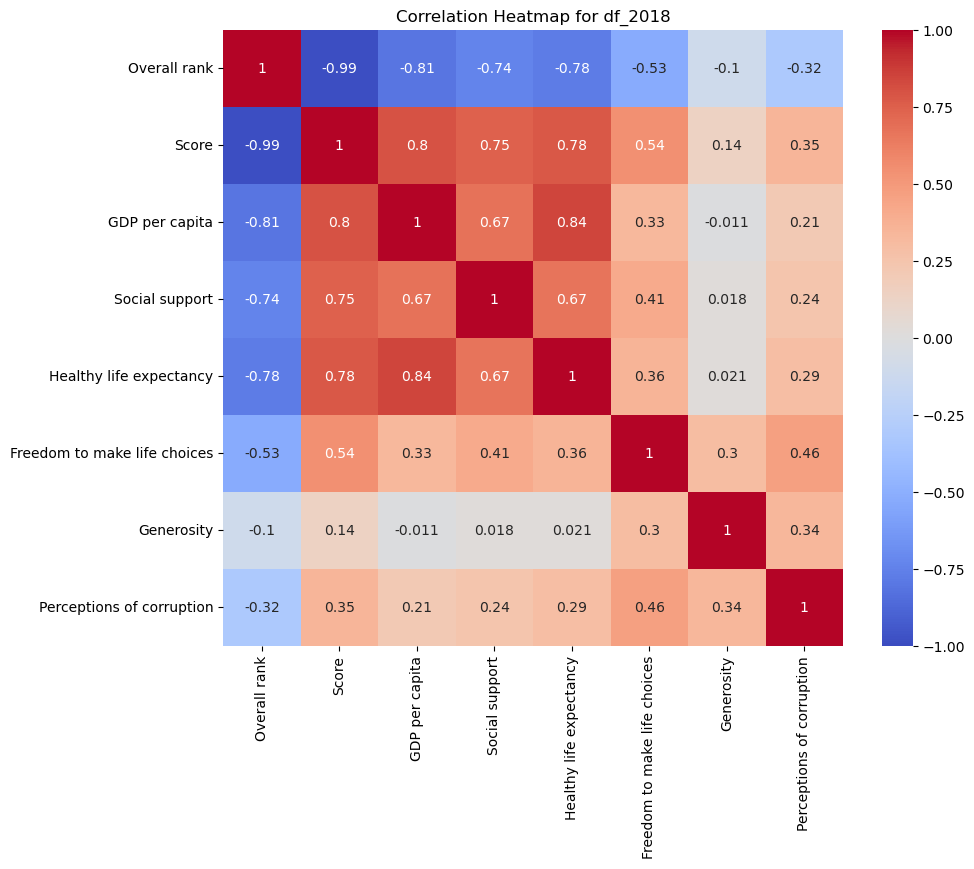

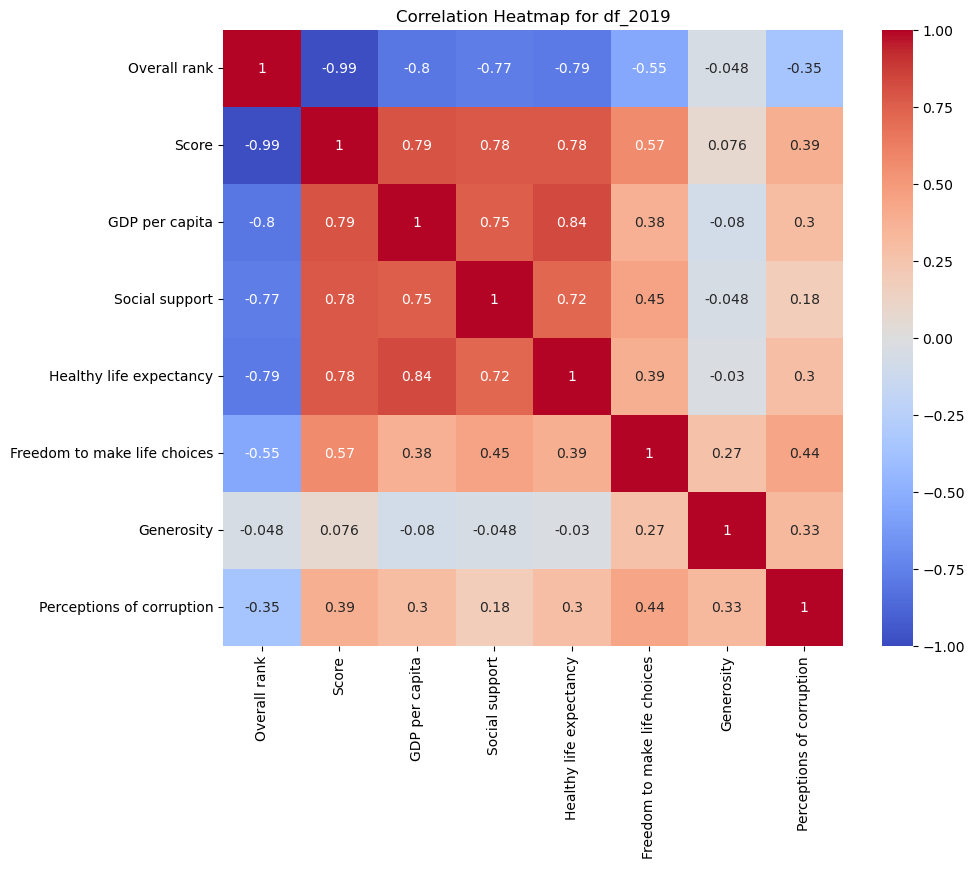

In [83]:
# Calculate the correlation matrix for df_2018 using only numerical columns
corr_2018 = df_2018[numerical_columns_18].corr()

# Create a heatmap for df_2018
plt.figure(figsize=(10, 8))
sns.heatmap(corr_2018, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap for df_2018')
plt.show()

# Calculate the correlation matrix for df_2019 using only numerical columns
corr_2019 = df_2019[numerical_columns_19].corr()

# Create a heatmap for df_2019
plt.figure(figsize=(10, 8))
sns.heatmap(corr_2019, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap for df_2019')
plt.show()

From the heatmap we can see that 'GDP per capita', 'Social support' and 'Healthy life expectancy' are the most factors effect the total score of happiness in a country.

#### Q2

In [97]:
# Merge the 2015 and 2016 datasets on the 'Country' column
df_2015_2016 = pd.merge(df_2015, df_2016, on='Country', suffixes=('_2015', '_2016'))

# Merge the 2016 and 2017 datasets on the 'Country' column
df_2016_2017 = pd.merge(df_2016, df_2017, on='Country', suffixes=('_2016', '_2017'))

# Calculate the rank change between 2015 and 2016
df_2015_2016['Rank Change'] = df_2015_2016['Happiness Rank_2015'] - df_2015_2016['Happiness Rank_2016']

# Calculate the rank change between 2016 and 2017
df_2016_2017['Rank Change'] = df_2016_2017['Happiness Rank'] - df_2016_2017['Happiness.Rank']

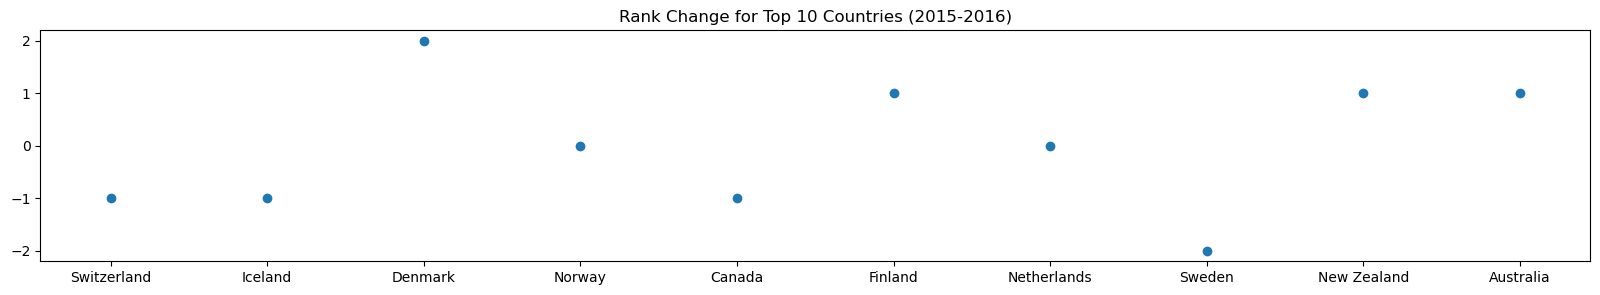

In [98]:
plt.figure(figsize=(20, 3))
# Create a scatter plot to visualize the rank change for the top 10 countries
plt.title('Rank Change for Top 10 Countries (2015-2016)')
plt.scatter(df_2015_2016['Country'][:10], df_2015_2016['Rank Change'][:10])

<Axes: title={'center': 'Rank Change Distribution (2015-2016)'}, xlabel='Rank Change'>

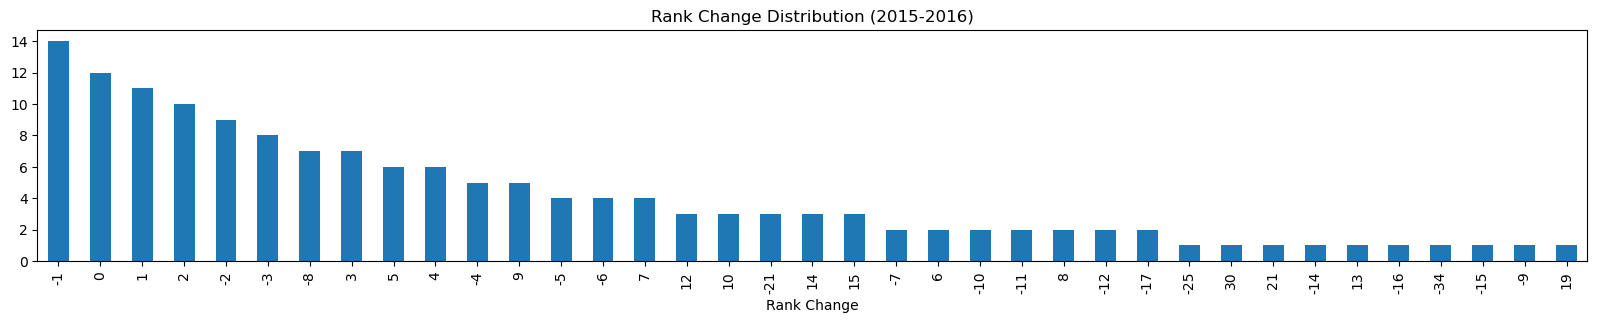

In [105]:
df_2015_2016['Rank Change'].value_counts().plot(kind='bar', figsize=(20, 3), title='Rank Change Distribution (2015-2016)')

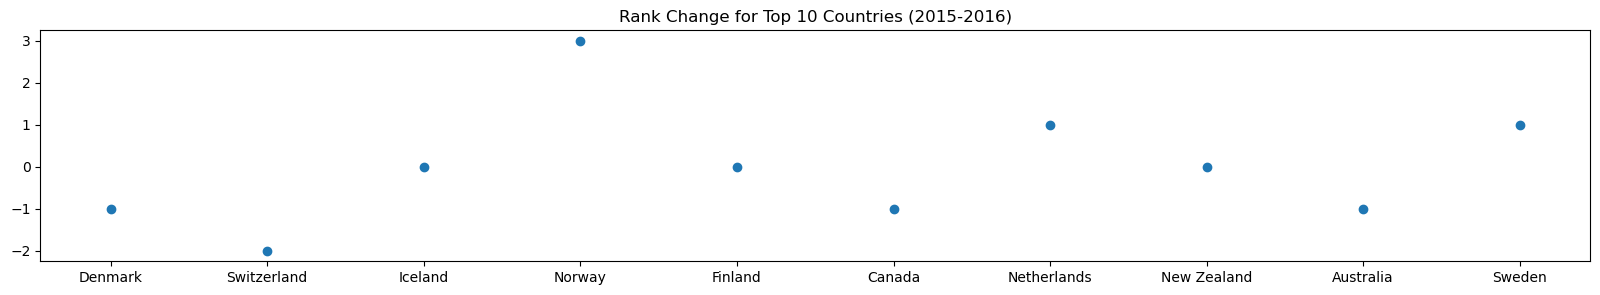

<Axes: title={'center': 'Rank Change Distribution (2016-2017)'}, xlabel='Rank Change'>

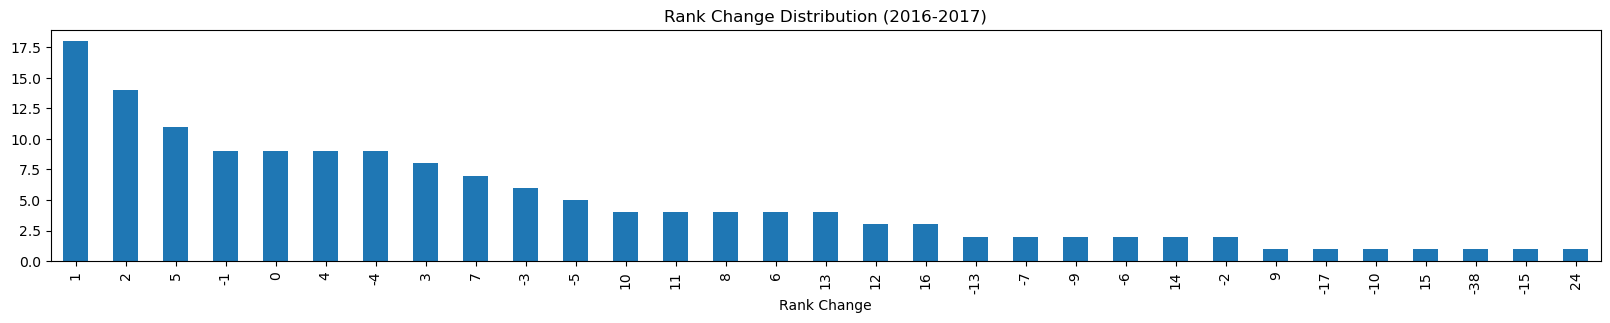

In [111]:
plt.figure(figsize=(20, 3))
# Create a scatter plot to visualize the rank change for the top 10 countries
plt.title('Rank Change for Top 10 Countries (2015-2016)')
plt.scatter(df_2016_2017['Country'][:10], df_2016_2017['Rank Change'][:10]) # Plot a scatter plot of the rank change for the top 10 countries
plt.show()

df_2016_2017['Rank Change'].value_counts().plot(kind='bar', figsize=(20, 3), title='Rank Change Distribution (2016-2017)') # Plot a bar chart of the rank change distribution

#### Q3

Countries with significant change in happiness:

Country with maximum rank change between 2015 and 2016: Algeria with a change of 30
Country with minimum rank change between 2015 and 2016: Liberia with a change of -34

Country with maximum rank change between 2016 and 2017: Bulgaria with a change of 24
Country with minimum rank change between 2016 and 2017: Venezuela with a change of -38

Country with maximum rank change between 2017 and 2018: Ghana with a change of 23
Country with minimum rank change between 2017 and 2018: Algeria with a change of -31

Country with maximum rank change between 2018 and 2019: Benin with a change of 34
Country with minimum rank change between 2018 and 2019: Malaysia with a change of -45


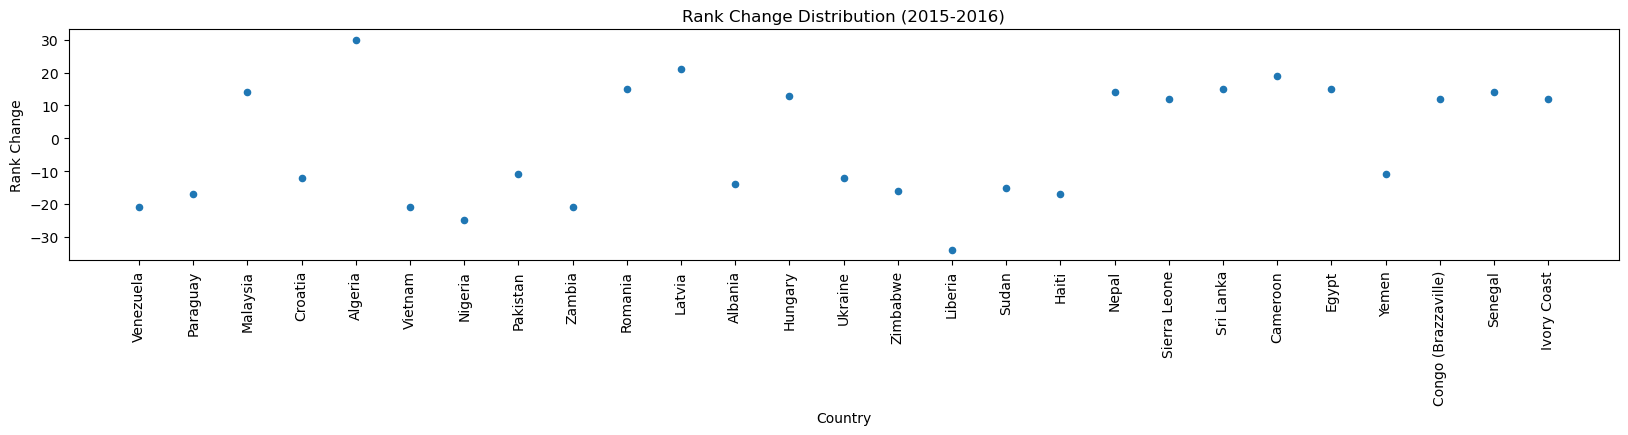

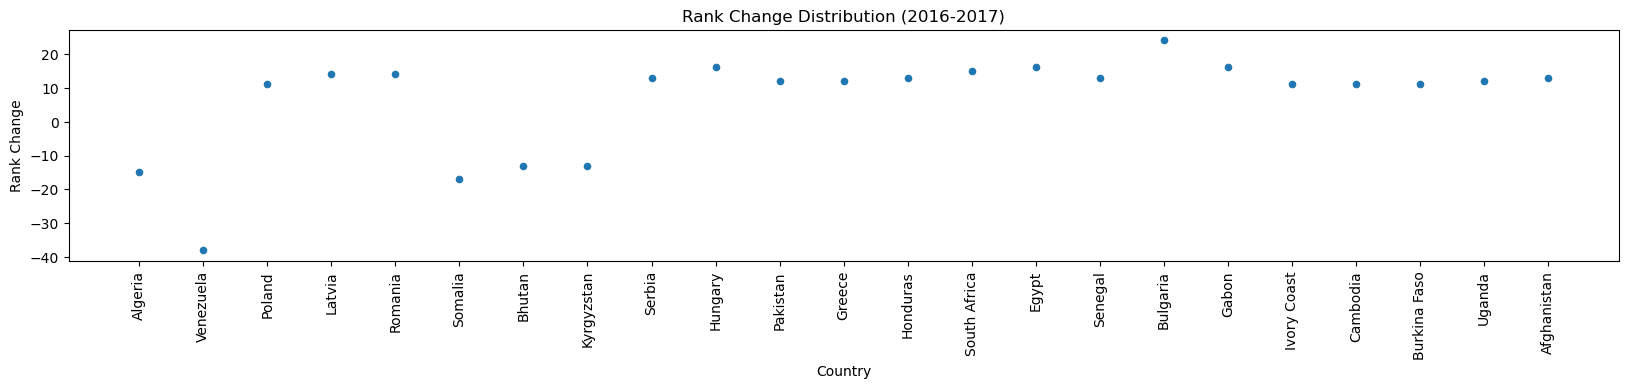

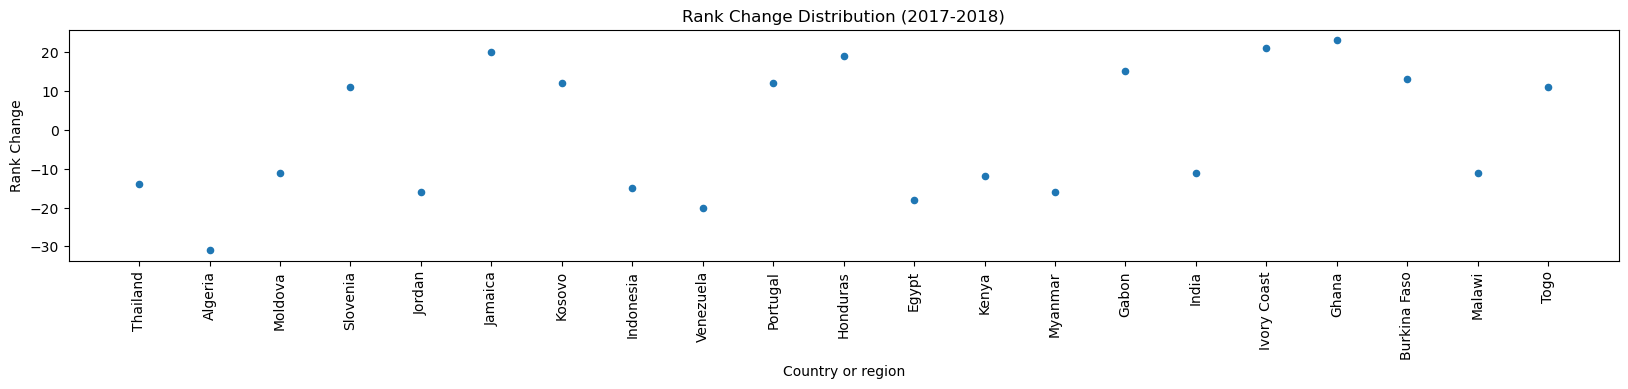

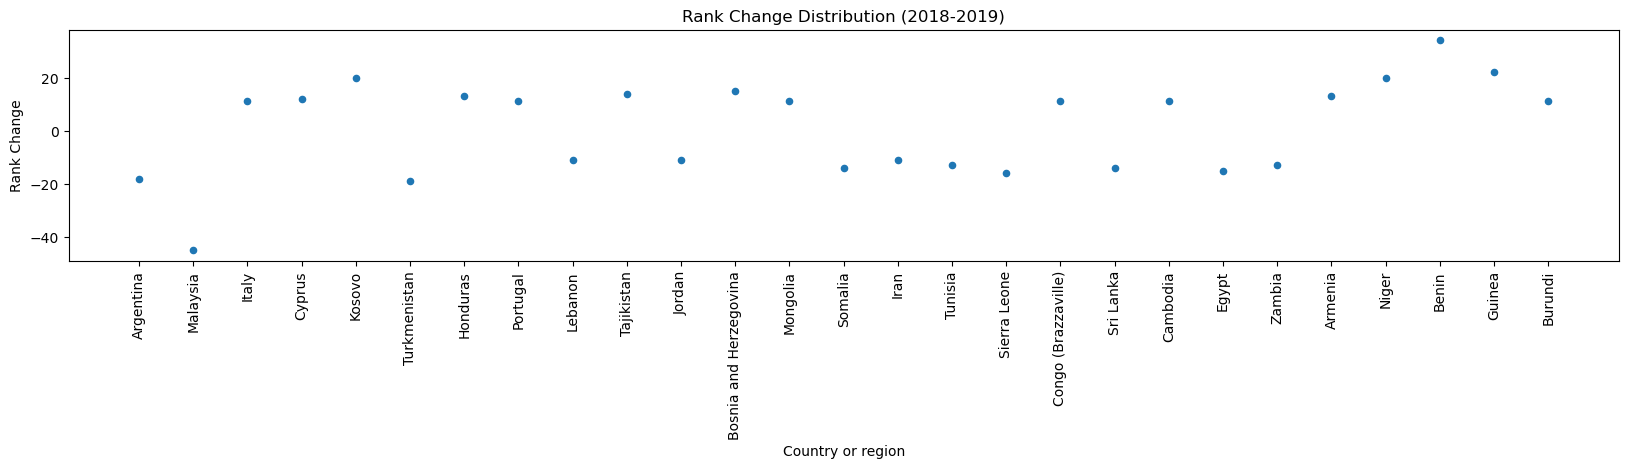

In [137]:
# Did any country experience a significant increase or decrease in happiness?

# Calculate the rank change between 2017 and 2018
df_2017_2018 = pd.merge(df_2017, df_2018, left_on='Country', right_on='Country or region', suffixes=('_2017', '_2018'))
df_2017_2018['Rank Change'] = df_2017_2018['Happiness.Rank'] - df_2017_2018['Overall rank']

# Calculate the rank change between 2018 and 2019
df_2018_2019 = pd.merge(df_2018, df_2019, on='Country or region', suffixes=('_2018', '_2019'))
df_2018_2019['Rank Change'] = df_2018_2019['Overall rank_2018'] - df_2018_2019['Overall rank_2019']
print("Countries with significant change in happiness:")

# Find countries with significant increase or decrease in happiness between 2015 and 2016
significant_change_2015_2016 = df_2015_2016[abs(df_2015_2016['Rank Change']) > 10]
significant_change_2015_2016.plot(kind='scatter', x='Country', y='Rank Change', figsize=(20, 3), title='Rank Change Distribution (2015-2016)', rot=90) # Plot a scatter chart of the rank change distribution with rotation
max_change = significant_change_2015_2016.loc[significant_change_2015_2016['Rank Change'].idxmax()]
min_change = significant_change_2015_2016.loc[significant_change_2015_2016['Rank Change'].idxmin()]

print(f"\nCountry with maximum rank change between 2015 and 2016: {max_change['Country']} with a change of {max_change['Rank Change']}")
print(f"Country with minimum rank change between 2015 and 2016: {min_change['Country']} with a change of {min_change['Rank Change']}")

# Find countries with significant increase or decrease in happiness between 2015 and 2016
significant_change_2016_2017 = df_2016_2017[abs(df_2016_2017['Rank Change']) > 10]
significant_change_2016_2017.plot(kind='scatter', x='Country', y='Rank Change', figsize=(20, 3), title='Rank Change Distribution (2016-2017)', rot=90) # Plot a scatter chart of the rank change distribution with rotation
max_change = significant_change_2016_2017.loc[significant_change_2016_2017['Rank Change'].idxmax()]
min_change = significant_change_2016_2017.loc[significant_change_2016_2017['Rank Change'].idxmin()]

print(f"\nCountry with maximum rank change between 2016 and 2017: {max_change['Country']} with a change of {max_change['Rank Change']}")
print(f"Country with minimum rank change between 2016 and 2017: {min_change['Country']} with a change of {min_change['Rank Change']}")


# Find countries with significant increase or decrease in happiness between 2017 and 2018
significant_change_2017_2018 = df_2017_2018[abs(df_2017_2018['Rank Change']) > 10]
significant_change_2017_2018.plot(kind='scatter', x='Country or region', y='Rank Change', figsize=(20, 3), title='Rank Change Distribution (2017-2018)', rot=90) # Plot a scatter chart of the rank change distribution with rotation
max_change = significant_change_2017_2018.loc[significant_change_2017_2018['Rank Change'].idxmax()]
min_change = significant_change_2017_2018.loc[significant_change_2017_2018['Rank Change'].idxmin()]

print(f"\nCountry with maximum rank change between 2017 and 2018: {max_change['Country or region']} with a change of {max_change['Rank Change']}")
print(f"Country with minimum rank change between 2017 and 2018: {min_change['Country or region']} with a change of {min_change['Rank Change']}")

# Find countries with significant increase or decrease in happiness between 2018 and 2019
significant_change_2018_2019 = df_2018_2019[abs(df_2018_2019['Rank Change']) > 10]
significant_change_2018_2019.plot(kind='scatter', x='Country or region', y='Rank Change', figsize=(20, 3), title='Rank Change Distribution (2018-2019)', rot=90) # Plot a scatter chart of the rank change distribution with rotation
max_change = significant_change_2018_2019.loc[significant_change_2018_2019['Rank Change'].idxmax()]
min_change = significant_change_2018_2019.loc[significant_change_2018_2019['Rank Change'].idxmin()]

print(f"\nCountry with maximum rank change between 2018 and 2019: {max_change['Country or region']} with a change of {max_change['Rank Change']}")
print(f"Country with minimum rank change between 2018 and 2019: {min_change['Country or region']} with a change of {min_change['Rank Change']}")